In [2]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [3]:
with open("20241109managementInsights3_personalization_context.json", "r") as fp:
    personalization_context = json.load(fp)

In [4]:
encoding_evolution = {group: np.array([
    [response["encoding"] 
     for response in personalization_context["responseStack"]
    ] for _, personalization_context in personalization_context.items() 
    if personalization_context["group"] == group]) for group in ["Treatment", "Control"]}

In [5]:
encoding_evolution["Treatment"].shape

(19, 11, 15)

In [27]:
hyperparameterLevels = {
    "exclude": [
      "[\"num__weekday\"]",
      "[\"num__windspeed\", \"num__weekday\"]",
      "[\"num__windspeed\"]",
      "[]"
    ],
    "interactions": [
      "1",
      "2",
      "3"
    ],
    "max_bins": [
      "8",
      "16",
      "256"
    ],
    "min_samples_leaf": [
      "64"
    ],
    "monotonicity_constraints": [
      "[\"num__atemp\", \"num__windspeed\"]",
      "[\"num__atemp\"]",
      "[\"num__windspeed\"]",
      "[]"
    ]
}

In [28]:
def plot_distribution(evolution, stack_pos: int):
    for i, (parameter_name, levels) in enumerate(hyperparameterLevels.items()):
        offset = sum([len(hyperparameterLevels[hp]) for hp in list(hyperparameterLevels.keys())[:i]])
        labels = [f"{parameter_name}: {l}" for l in levels]
        plt.bar(x = labels, height=evolution[:,stack_pos,:].sum(axis=0)[offset:offset+len(levels)])
        plt.xticks(rotation=90)

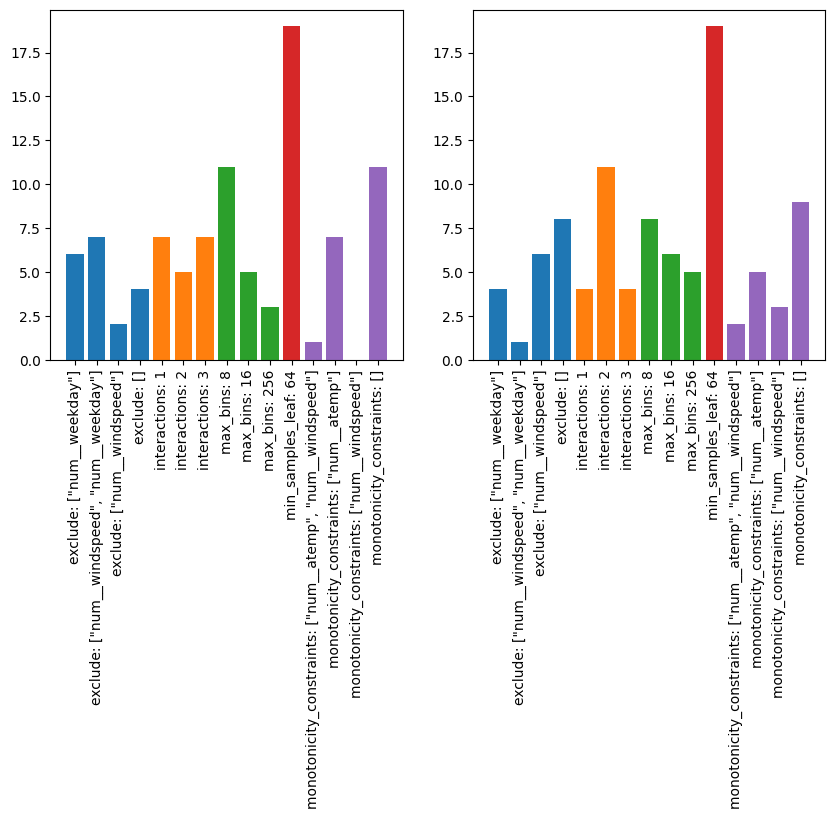

In [29]:
plt.figure(figsize=(10,10))
plt.subplot(2,2,1)
plot_distribution(encoding_evolution["Treatment"], -1)
plt.subplot(2,2,2)
plot_distribution(encoding_evolution["Treatment"], 0)
#plt.subplot(2,2,3)
#plot_distribution(encoding_evolution["Control"], -1)
#plt.subplot(2,2,4)
#plot_distribution(encoding_evolution["Control"], 0)


In [30]:
reward_evolution = {group: np.array([
    [int(response["reward"])
     for response in personalization_context["requestStack"]
    ] for _, personalization_context in personalization_context.items() 
    if personalization_context["group"] == group]) for group in ["Treatment", "Control"]}

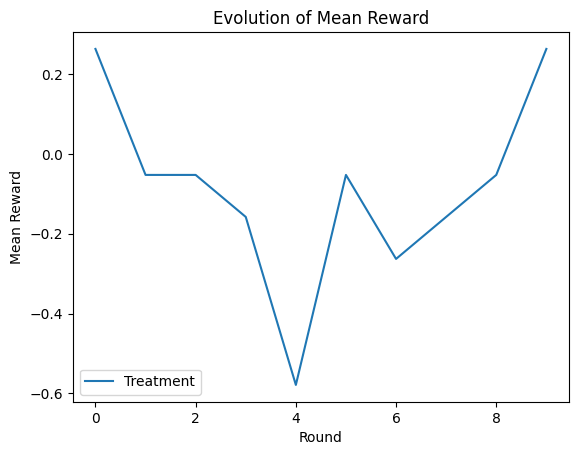

In [31]:
# how do the mean rewards evolve over the rounds?

plt.title("Evolution of Mean Reward")
plt.plot(reward_evolution["Treatment"].mean(axis=0)[::-1])
#plt.plot(reward_evolution["Control"].mean(axis=0)[::-1])
plt.xlabel("Round")
plt.ylabel("Mean Reward")
plt.legend(["Treatment", "Control"])

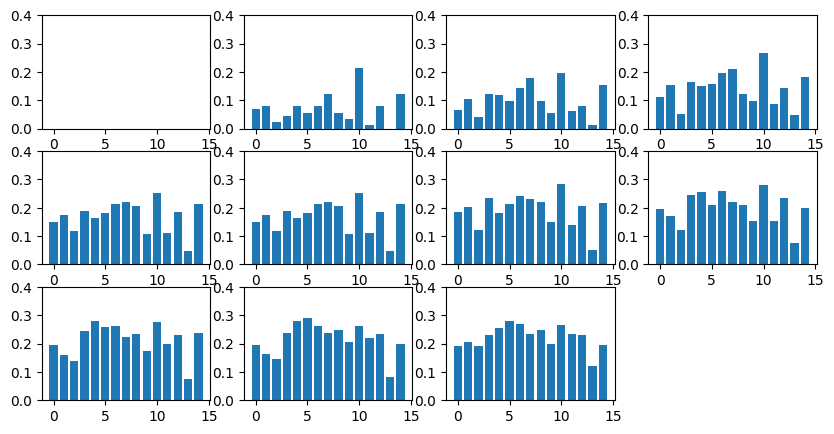

In [32]:
# how does the mean absolute value of the reward model's weights evolve?

mu_evolution = {group: np.array([
    [response["userContext"]["mu"]
     for response in personalization_context["responseStack"]
    ] for _, personalization_context in personalization_context.items() 
    if personalization_context["group"] == group]) for group in ["Treatment", "Control"]}

plt.figure(figsize=(10,5))
# create plot for every personalization round
for i in range(11):
    plt.subplot(3,4,i+1)
    plt.ylim(0,0.4)
    plt.bar(range(15), height = np.absolute(mu_evolution["Treatment"]).mean(axis=0)[-(i+1),:])

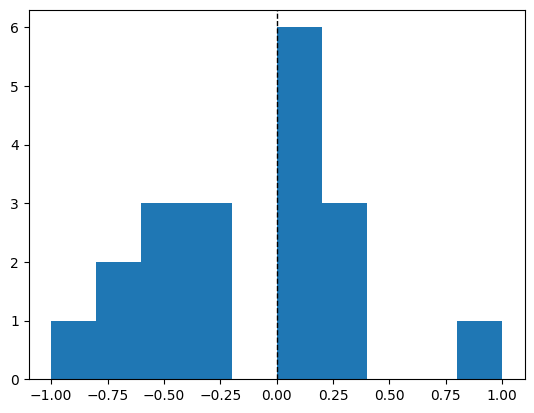

In [33]:
# reward calibration - how do we need so set the reward so that there users rate (approx.) 50% of dashboards as good / bad

control_userinput_evolution = np.array([
    [int(response["reward"])
     for response in personalization_context["requestStack"]
    ] for _, personalization_context in personalization_context.items() 
    if personalization_context["group"] == "Treatment"])

# mean over rounds -> every datum corresponds to the mean for a user
plt.hist(np.mean(control_userinput_evolution, axis=1))
plt.axvline(np.median(np.mean(control_userinput_evolution, axis=1)), color='k', linestyle='dashed', linewidth=1)

Text(0.5, 1.0, 'Control')

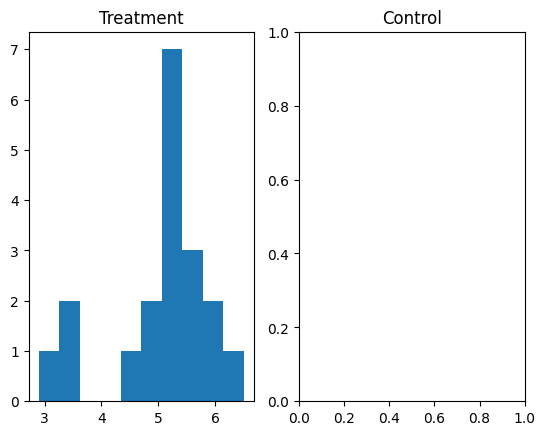

In [34]:
control_evolution = {group: np.array([
    [int(response["userInput"])
     for response in personalization_context["requestStack"]
    ] for _, personalization_context in personalization_context.items() 
    if personalization_context["group"] == group]) for group in ["Control", "Treatment"]}

plt.subplot(1,2,1)
plt.title("Treatment")
# mean over rounds -> every datum corresponds to the mean for a user
plt.hist(control_evolution["Treatment"].mean(axis=1))
plt.subplot(1,2,2)
plt.title("Control")
# mean over rounds -> every datum corresponds to the mean for a user
#plt.hist(control_evolution["Control"].mean(axis=1))

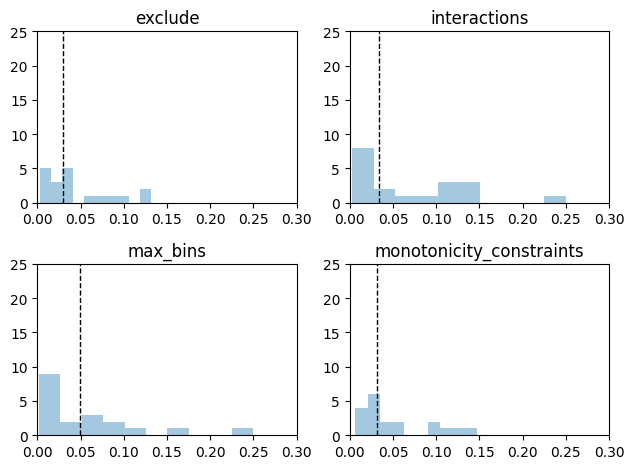

In [35]:
# hyperparameter variance - do we learn differences between hyperparameter levels?

def hyperparameter_variance(evolution, stack_pos: int):
    variances = {}
    for i, (parameter_name, levels) in enumerate(hyperparameterLevels.items()):
        offset = sum([len(hyperparameterLevels[hp]) for hp in list(hyperparameterLevels.keys())[:i]])
        labels = [f"{parameter_name}: {l}" for l in levels]
        variances[parameter_name] = evolution[:,stack_pos,offset:offset+len(levels)].var(axis=1)
    return variances   

variances = hyperparameter_variance(mu_evolution["Treatment"], 0)
hyperparameters = ["exclude", "interactions", "max_bins", "monotonicity_constraints"]
for i, hyperparameter in enumerate(hyperparameters):
    plt.subplot(2,2,i+1)
    plt.title(hyperparameter)
    plt.xlim(0,0.3)
    plt.ylim(0,25)
    plt.hist(variances[hyperparameter], alpha=0.4)
    plt.axvline(np.median(variances[hyperparameter]), color='k', linestyle='dashed', linewidth=1)
plt.tight_layout()

In [36]:
rating_by_hyperparameter_level = {group: np.array([
    [int(request["userInput"]) * np.array(response["encoding"])
     for request, response in zip(personalization_context["requestStack"], personalization_context["responseStack"][1:])
    ] for _, personalization_context in personalization_context.items() 
    if personalization_context["group"] == group]) for group in ["Treatment", "Control"]}

encoding_evolution["Treatment"].shape

(19, 11, 15)

In [62]:
A = np.array([[1,2],[3,4]])

In [63]:
A[:,[1,0]]

array([[2, 1],
       [4, 3]])

In [94]:
user_id = "494f50c6-e75c-4626-903d-134a560b4b90"
user_index = 13
rating_data = rating_by_hyperparameter_level["Treatment"][user_index,:,:]
mu_data = mu_evolution["Treatment"][user_index,0,:]
positions = [3, 0, 2, 1, 4, 5, 6, 7, 8, 9, 14, 12, 13, 11]
mu_data_reshuffled = mu_data[positions]
rating_data_reshuffled = rating_data[:, positions]
print(hyperparameterLevelList)

['exclude: ["num__weekday"]', 'exclude: ["num__windspeed", "num__weekday"]', 'exclude: ["num__windspeed"]', 'exclude: []', 'interactions: 1', 'interactions: 2', 'interactions: 3', 'max_bins: 8', 'max_bins: 16', 'max_bins: 256', 'min_samples_leaf: 64', 'monotonicity_constraints: ["num__atemp", "num__windspeed"]', 'monotonicity_constraints: ["num__atemp"]', 'monotonicity_constraints: ["num__windspeed"]', 'monotonicity_constraints: []']


In [95]:
for p in positions:
    print(hyperparameterLevelList[p])

exclude: []
exclude: ["num__weekday"]
exclude: ["num__windspeed"]
exclude: ["num__windspeed", "num__weekday"]
interactions: 1
interactions: 2
interactions: 3
max_bins: 8
max_bins: 16
max_bins: 256
monotonicity_constraints: []
monotonicity_constraints: ["num__atemp"]
monotonicity_constraints: ["num__windspeed"]
monotonicity_constraints: ["num__atemp", "num__windspeed"]


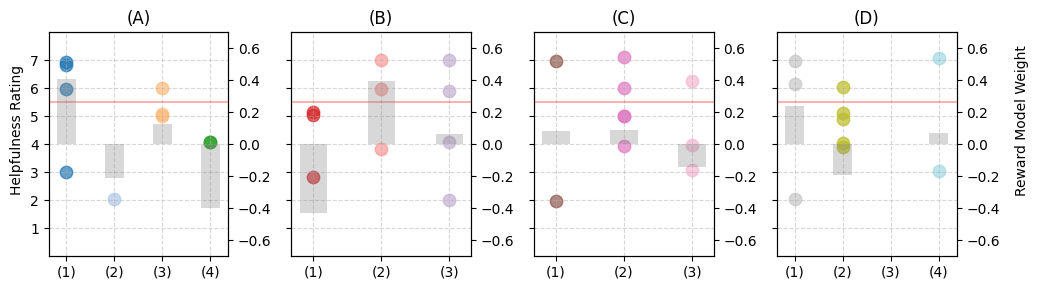

In [127]:
hyperparameterLevels = {
    "exclude": [
      "[]",
      "[\"num__weekday\"]",
      "[\"num__windspeed\"]",
      "[\"num__windspeed\", \"num__weekday\"]",
    ],
    "interactions": [
      "1",
      "2",
      "3"
    ],
    "max_bins": [
      "8",
      "16",
      "256"
    ],
    "monotonicity_constraints": [
      "[]",
      "[\"num__atemp\"]",
      "[\"num__windspeed\"]",  
      "[\"num__atemp\", \"num__windspeed\"]",
    ]
}

num_columns = 14 #encoding_evolution["Treatment"].shape[1]
colors = plt.cm.tab20(np.linspace(0, 1, num_columns))  # Choose a distinct color for each column

# Create subplots with one row and as many columns as parameters
fig, axes = plt.subplots(1, len(hyperparameterLevels), figsize=(10, 3), sharey=True)

#fig.suptitle(f"user {user_id}", fontsize=16)

# Loop through hyperparameter levels to plot each subplot
for i, (parameter_name, levels) in enumerate(hyperparameterLevels.items()):

    offset = sum([len(hyperparameterLevels[hp]) for hp in list(hyperparameterLevels.keys())[:i]])
    ax = axes[i]  # Current subplot axis

    for j, col in enumerate(range(offset, offset + len(levels))):
        # Get the non-zero ratings and corresponding row indices (time steps) for this column
        row_indices = np.nonzero(rating_data_reshuffled[:, col])[0]
        ratings = rating_data_reshuffled[row_indices, col] + np.random.normal(0, 0.08, size=row_indices.shape)
        
        # Plot each column's points with a distinct color
        ax.scatter([j] * len(ratings), ratings, color=colors[col], s=80, alpha=0.7)

    # Set labels and title for each subplot
    alphabet = "ABCDDD"
    ax.set_title(f"({alphabet[i]})")
    ax.set_ylim(0, 8)
    ax.set_yticks(range(1,8))
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.axhline(5.5, color="red", alpha=0.3)

    # Set custom x-tick labels for each column
    ax.set_xticks(range(len(levels)))
    ax.set_xticklabels([f"({k+1})" for k in range(len(levels))])
    # Add a second y-axis for the secondary quantity (bar plot)
    ax_secondary = ax.twinx()
    ax_secondary.bar(range(len(levels)), mu_data_reshuffled[offset:offset+len(levels)], color="gray", alpha=0.3, width=0.4, label="Secondary Quantity")

    # Set secondary y-axis label
    ax_secondary.set_ylim(-0.7, 0.7)

# Global y-axis label
fig.text(-0.005, 0.55, 'Helpfulness Rating', va='center', rotation='vertical')
fig.text(1, 0.58, 'Reward Model Weight', va='center', rotation='vertical')
plt.tight_layout()
plt.savefig(f"paper_plot_personalization_result_{user_id}.svg", bbox_inches="tight")


In [71]:
hyperparameterLevelList = [f"{name}: {level}" for name,levels in hyperparameterLevels.items() for level in levels]

13


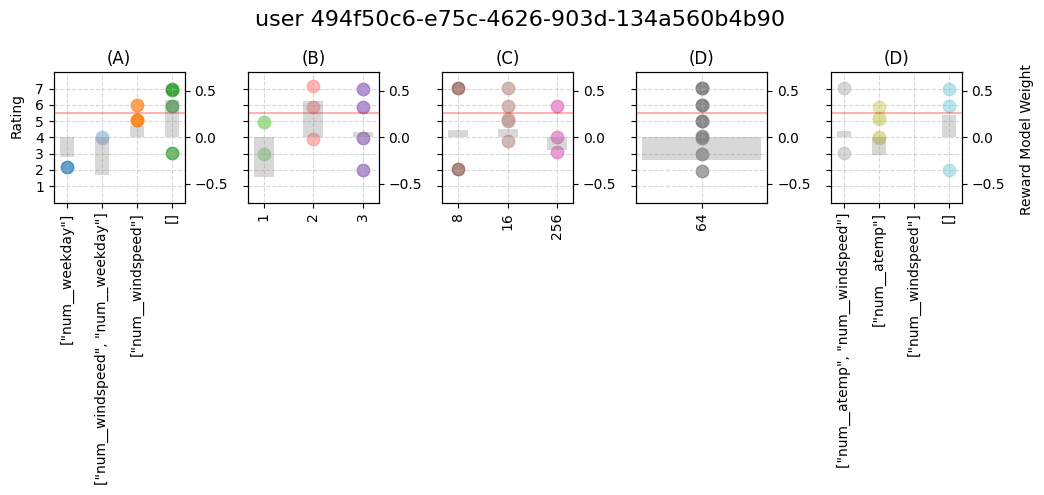

In [61]:
for user_index in range(encoding_evolution["Treatment"].shape[0]):
    
    rating_data = rating_by_hyperparameter_level["Treatment"][user_index,:,:]
    mu_data = mu_evolution["Treatment"][user_index,0,:]
    user_id =list(personalization_context.keys())[user_index]
    if user_id != "494f50c6-e75c-4626-903d-134a560b4b90": continue
    print(user_index)
    
    num_columns = 15 #encoding_evolution["Treatment"].shape[1]
    colors = plt.cm.tab20(np.linspace(0, 1, num_columns))  # Choose a distinct color for each column

    # Create subplots with one row and as many columns as parameters
    fig, axes = plt.subplots(1, len(hyperparameterLevels), figsize=(10, 5), sharey=True)

    fig.suptitle(f"user {user_id}", fontsize=16)

    # Loop through hyperparameter levels to plot each subplot
    for i, (parameter_name, levels) in enumerate(hyperparameterLevels.items()):

        offset = sum([len(hyperparameterLevels[hp]) for hp in list(hyperparameterLevels.keys())[:i]])
        ax = axes[i]  # Current subplot axis

        for j, col in enumerate(range(offset, offset + len(levels))):
            # Get the non-zero ratings and corresponding row indices (time steps) for this column
            row_indices = np.nonzero(rating_data[:, col])[0]
            ratings = rating_data[row_indices, col] + np.random.normal(0, 0.08, size=row_indices.shape)

            # Plot each column's points with a distinct color
            ax.scatter([j] * len(ratings), ratings, color=colors[col], s=80, alpha=0.7)

        # Set labels and title for each subplot
        alphabet = "ABCDDD"
        ax.set_title(f"({alphabet[i]})")
        ax.set_ylim(0, 8)
        ax.set_yticks(range(1,8))
        ax.grid(True, linestyle="--", alpha=0.5)
        ax.axhline(5.5, color="red", alpha=0.3)

        # Set custom x-tick labels for each column
        ax.set_xticks(range(len(levels)))
        ax.set_xticklabels(levels, rotation=90)
        # Add a second y-axis for the secondary quantity (bar plot)
        ax_secondary = ax.twinx()
        ax_secondary.bar(range(len(levels)), mu_data[offset:offset+len(levels)], color="gray", alpha=0.3, width=0.4, label="Secondary Quantity")

        # Set secondary y-axis label
        ax_secondary.set_ylim(-0.7, 0.7)

    # Global y-axis label
    fig.text(-0.01, 0.77, 'Rating', va='center', rotation='vertical')
    fig.text(1, 0.72, 'Reward Model Weight', va='center', rotation='vertical')
    plt.tight_layout()
    #plt.savefig(f"personalization_result_{user_id}.png", bbox_inches="tight")


In [21]:
mu_evolution["Treatment"][0,0,:]

array([-0.38579865,  0.05822817,  0.36851911, -0.25240331, -0.03684852,
        0.04410105, -0.15676574,  0.20649172, -0.28980602, -0.25240331,
       -0.03128565, -0.25240331,  0.13707461,  0.        , -0.06152149])

In [24]:
print([d["id"] for d in personalization_context['4bce57e3-79c6-4456-818f-4f581be1f5aa']["responseStack"]])
print([d["id"] for d in personalization_context['4bce57e3-79c6-4456-818f-4f581be1f5aa']["requestStack"]])

['7ada702b-06cf-4d37-aee7-3e6778d77c17', '3ebdf17b-6b9c-453b-8e4a-ca03e4f19d40', '68b454de-4866-4edb-948d-1c2c70c2885f', 'f98faac1-fb36-41e1-91c2-b987b1ef568c', '22703f90-6bf3-459c-aa32-b1582849ccf9', '9a6f20aa-33c2-4259-bedf-bc25a25c476b', 'b82e04b1-e96a-4b50-9ad8-48d26609f285', '180a2b48-816f-4ffe-a5ac-bdeb5b6124af', '3dde22e8-0fa1-4576-9f04-dbdacfb41479', 'bb841997-4988-4fde-9984-0e2650ed4f01', 'e8bfcc30-a3c8-4f63-bd1b-372219e7ccf7']
['3ebdf17b-6b9c-453b-8e4a-ca03e4f19d40', '68b454de-4866-4edb-948d-1c2c70c2885f', 'f98faac1-fb36-41e1-91c2-b987b1ef568c', '22703f90-6bf3-459c-aa32-b1582849ccf9', '9a6f20aa-33c2-4259-bedf-bc25a25c476b', 'b82e04b1-e96a-4b50-9ad8-48d26609f285', '180a2b48-816f-4ffe-a5ac-bdeb5b6124af', '3dde22e8-0fa1-4576-9f04-dbdacfb41479', 'bb841997-4988-4fde-9984-0e2650ed4f01', 'e8bfcc30-a3c8-4f63-bd1b-372219e7ccf7']


In [ ]:
personalization_context